In [21]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("MSE446_cleaned_dataset.csv")

In [11]:
df["date"] = pd.to_datetime(df["date"])
# Data Set Overview 
print("Dataset Shape:")
print(df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.head()

Dataset Shape:
(3236, 124)

Column Types:
listing_id                                           int64
date                                        datetime64[ns]
vacant_days                                          int64
reserved_days                                        int64
occupancy                                          float64
                                                 ...      
cancellation_policy_Flexible                         int64
cancellation_policy_Limited                          int64
cancellation_policy_Moderate                         int64
cancellation_policy_Strict                           int64
cancellation_policy_Super Strict 30 Days             int64
Length: 124, dtype: object

Missing Values:
listing_id     0
rain_v         0
is_may         0
is_march       0
is_june        0
is_july        0
is_february    0
is_august      0
is_april       0
month          0
dtype: int64

Duplicate Rows:
0


,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


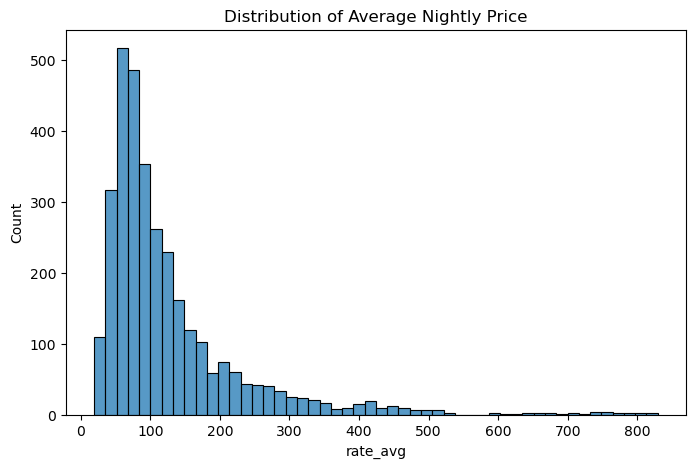

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["rate_avg"], bins=50)
plt.title("Distribution of Average Nightly Price")
plt.xlabel("rate_avg")
plt.show()

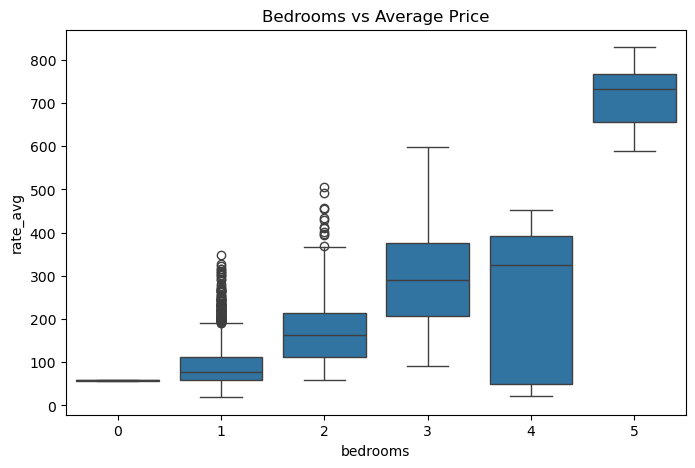

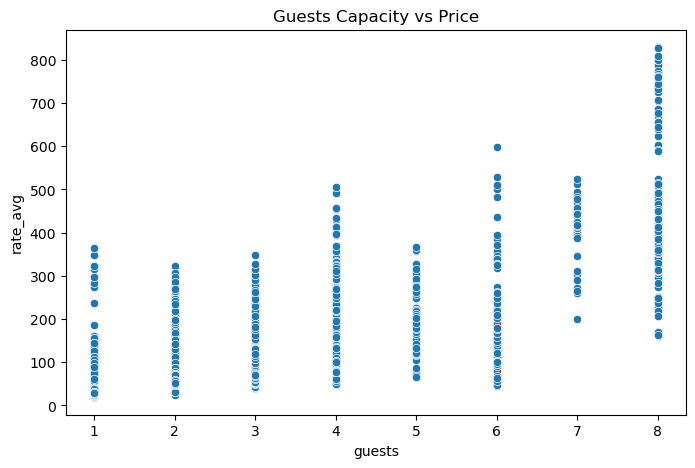

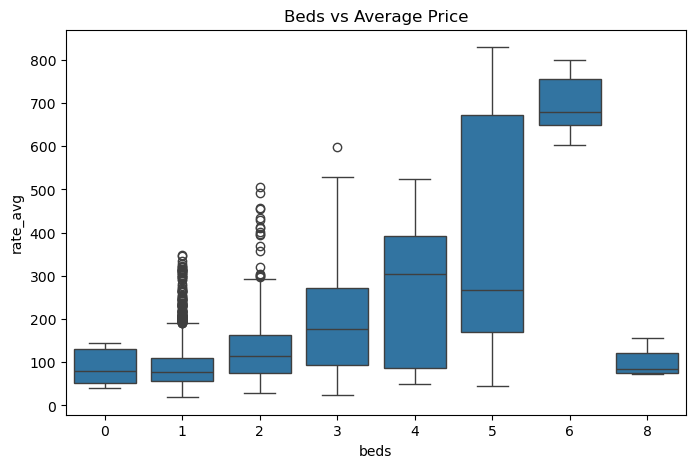

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["bedrooms"], y=df["rate_avg"])
plt.title("Bedrooms vs Average Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["guests"], y=df["rate_avg"])
plt.title("Guests Capacity vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["beds"], y=df["rate_avg"])
plt.title("Beds vs Average Price")
plt.show()

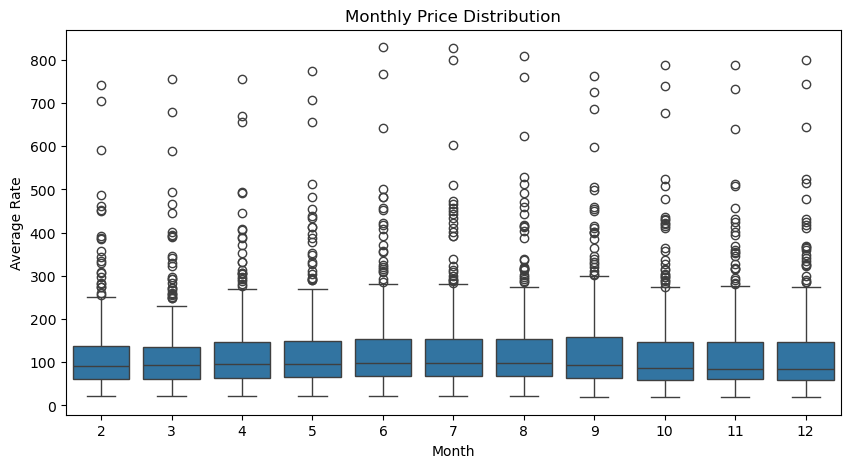

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["date"].dt.month, y=df["rate_avg"])
plt.title("Monthly Price Distribution")
plt.xlabel("Month")
plt.ylabel("Average Rate")
plt.show()


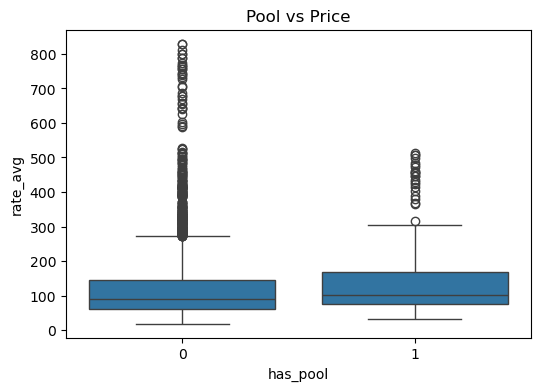

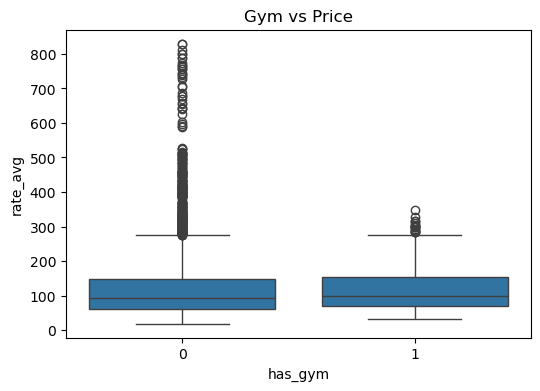

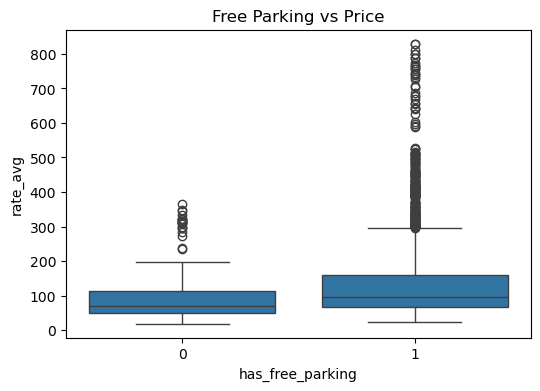

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_pool"], y=df["rate_avg"])
plt.title("Pool vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_gym"], y=df["rate_avg"])
plt.title("Gym vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_free_parking"], y=df["rate_avg"])
plt.title("Free Parking vs Price")
plt.show()

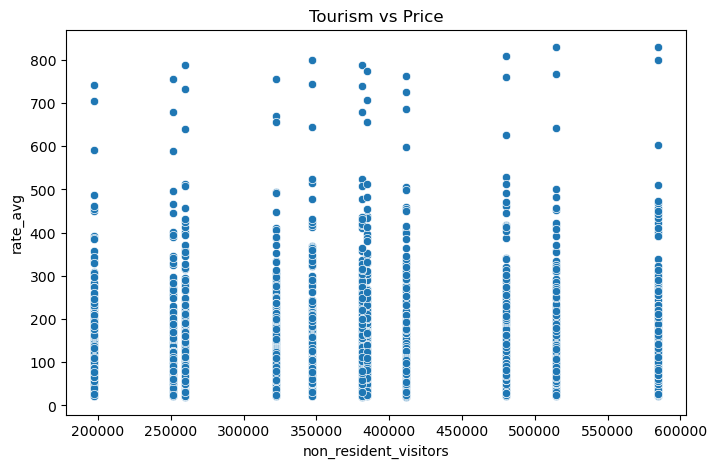

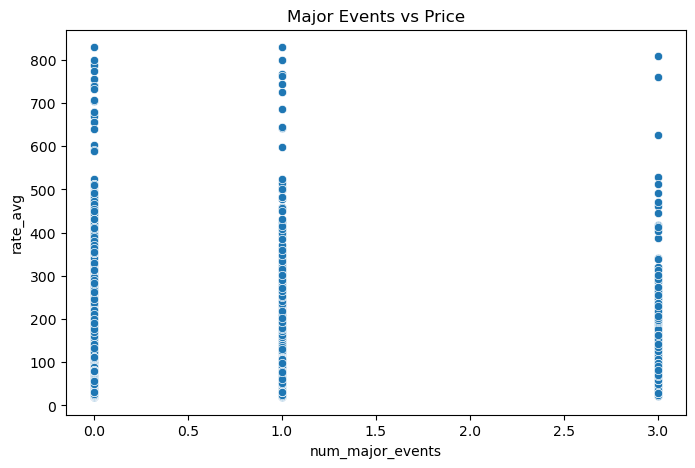

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["non_resident_visitors"], y=df["rate_avg"])
plt.title("Tourism vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["num_major_events"], y=df["rate_avg"])
plt.title("Major Events vs Price")
plt.show()

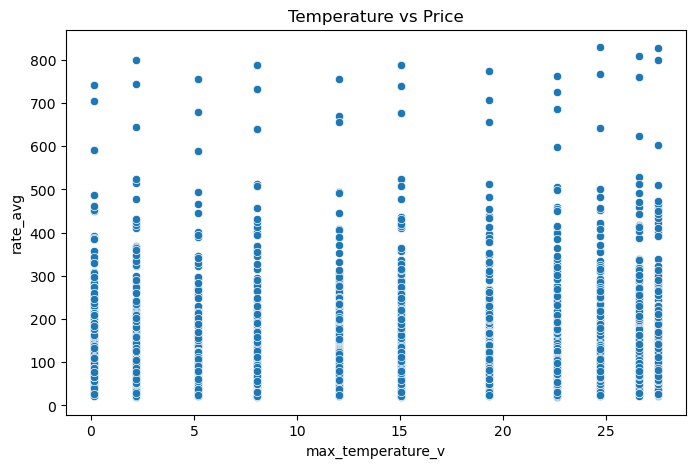

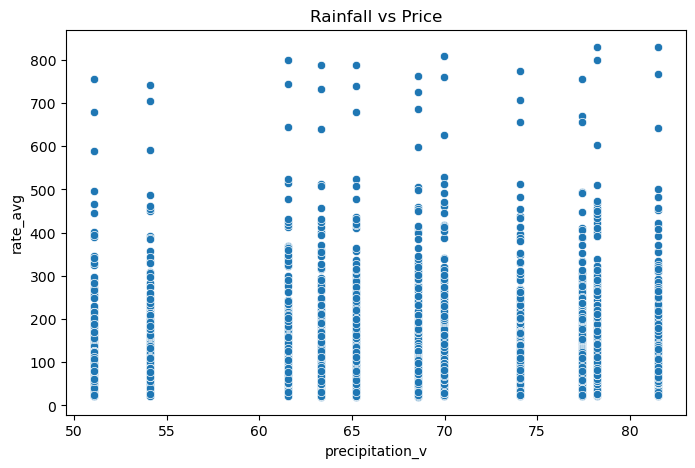

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["max_temperature_v"], y=df["rate_avg"])
plt.title("Temperature vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["precipitation_v"], y=df["rate_avg"])
plt.title("Rainfall vs Price")
plt.show()



In [18]:
corr_target = df.corr()["rate_avg"].sort_values(ascending=False)

print("\nTop 20 Features Correlated with Price:")
print(corr_target.head(50))


Top 20 Features Correlated with Price:
rate_avg                           1.000000
ttm_avg_rate_native                0.974066
ttm_avg_rate                       0.974062
l90d_avg_rate                      0.926502
l90d_avg_rate_native               0.926488
bedrooms                           0.728454
guests                             0.720947
baths                              0.642458
ttm_revpar                         0.620521
ttm_revpar_native                  0.620055
ttm_revenue                        0.618774
ttm_revenue_native                 0.618357
beds                               0.567727
ttm_adjusted_revpar                0.517727
ttm_adjusted_revpar_native         0.517148
revenue                            0.497300
listing_type_Entire home           0.484531
cleaning_fee                       0.369838
l90d_revenue                       0.329042
l90d_revenue_native                0.329030
l90d_revpar_native                 0.326210
l90d_revpar                        0

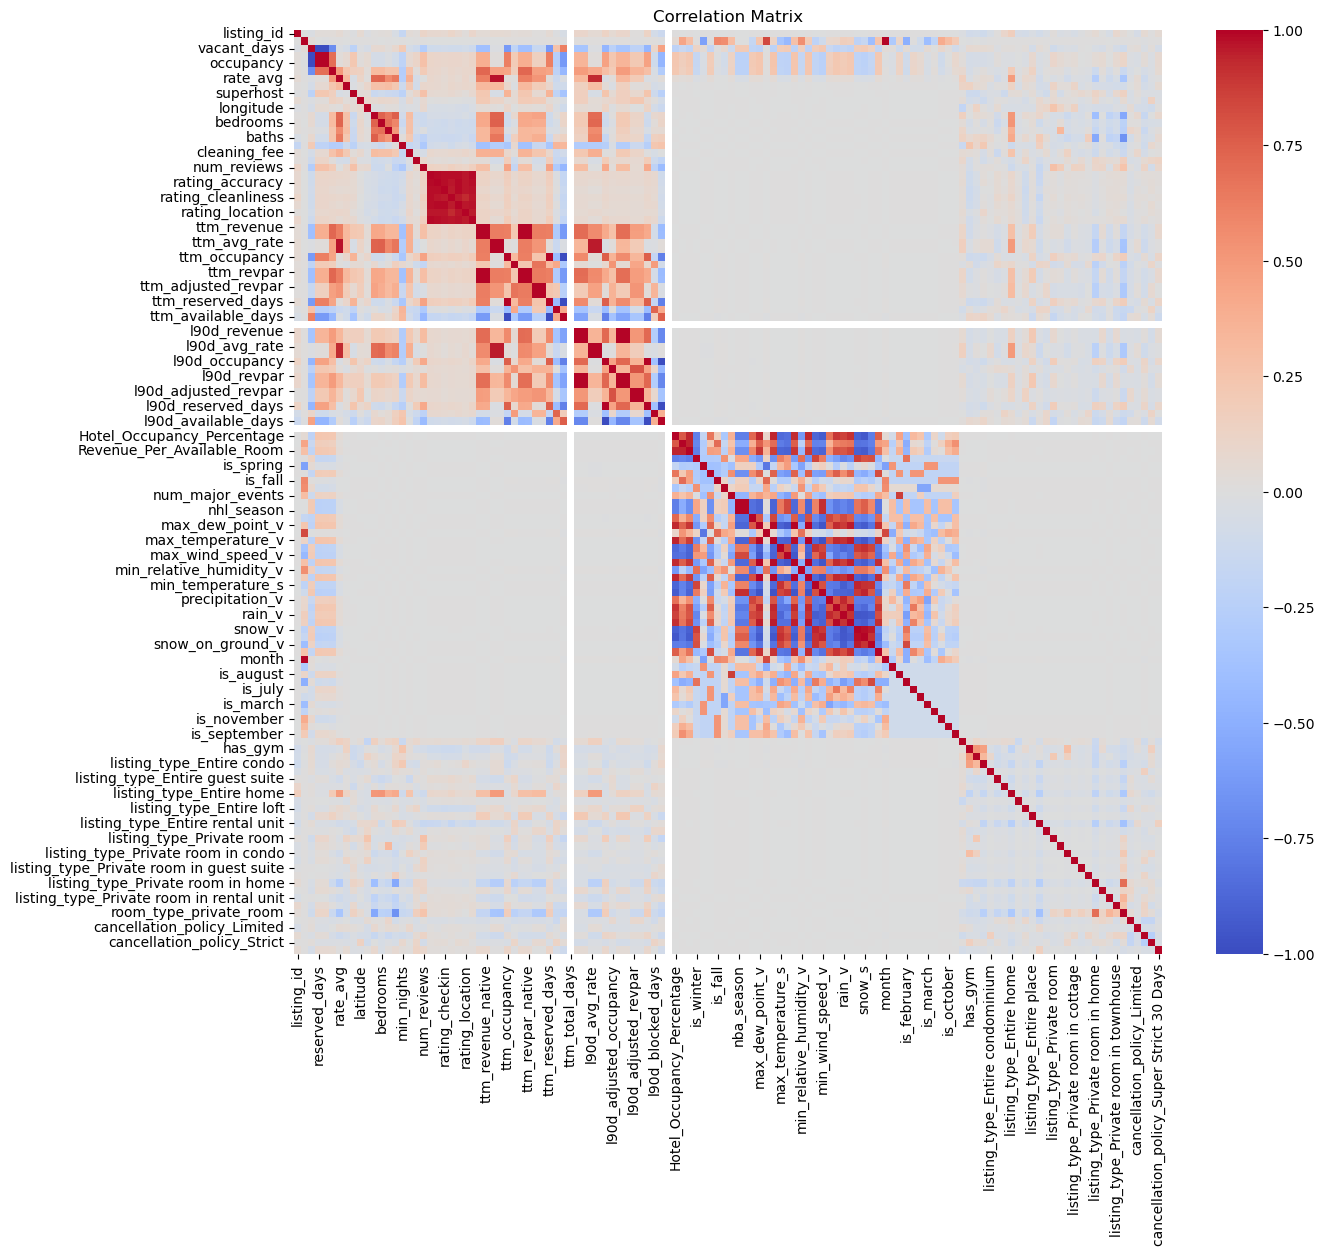

In [19]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

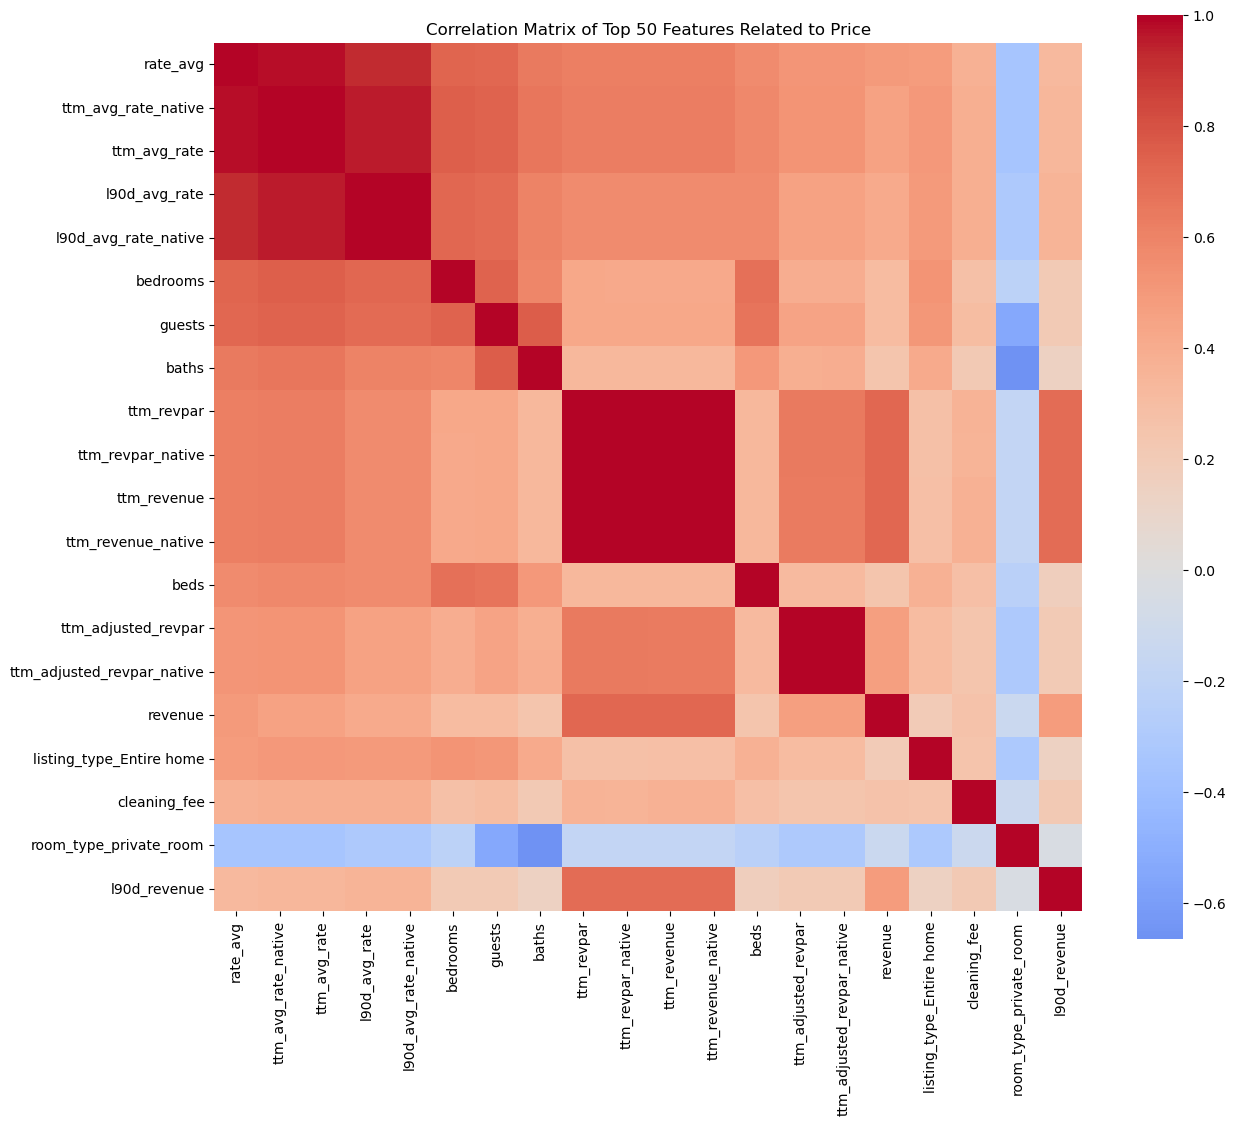

In [26]:
corr_with_target = df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.head(20).index
top_corr_matrix = df[top_20_features].corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    top_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Top 50 Features Related to Price")

plt.show()

In [23]:
import numpy as np 

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)  
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("\nHighly Correlated Features (>0.9):")
print(high_corr)


Highly Correlated Features (>0.9):
['reserved_days', 'occupancy', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_available_days', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_available_days', 'Revenue_Per_Available_Room', 'nhl_season', 'max_dew_point_v', 'max_temperature_v', 'max_wind_speed_v', 'min_dew_point_v', 'min_temperature_v', 'min_temperature_s', 'min_wind_speed_v', 'precipitation_s', 'rain_v', 'rain_s', 'snow_v', 'snow_s', 'snow_on_ground_v', 'non_resident_visitors', 'month']
